In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

label_df = pd.read_csv('data\labels.csv.')
people_df = pd.read_csv('data\kyc_individual.csv')
business_df = pd.read_csv('data\kyc_smallbusiness.csv')
abm_df = pd.read_csv(r'data\abm.csv')
card_df = pd.read_csv('data\card.csv')
cheque_df = pd.read_csv('data\cheque.csv')
eft_df = pd.read_csv('data\eft.csv')
emt_df = pd.read_csv('data\emt.csv')
western_union_df = pd.read_csv('data\westernunion.csv')
wire_df = pd.read_csv('data\wire.csv')

#CONSTANTS
ID = 'customer_id'


In [16]:
master_df = pd.read_csv('data\master_data.csv')

C:\Users\silve\AppData\Local\Temp\ipykernel_8924\2294859533.py:1: DtypeWarning: Columns (0,3,4,6,7,8,9,10,11,12,13,14,15,17,18,19,20,21,22,23,24,25,28,29,30,31,32,34,35,36,38,39,40,41,43,44,45,47,48,49,51,52,53,55,57,58,59,61,62,63) have mixed types. Specify dtype option on import or set low_memory=False.
  master_df = pd.read_csv('data\master_data.csv')


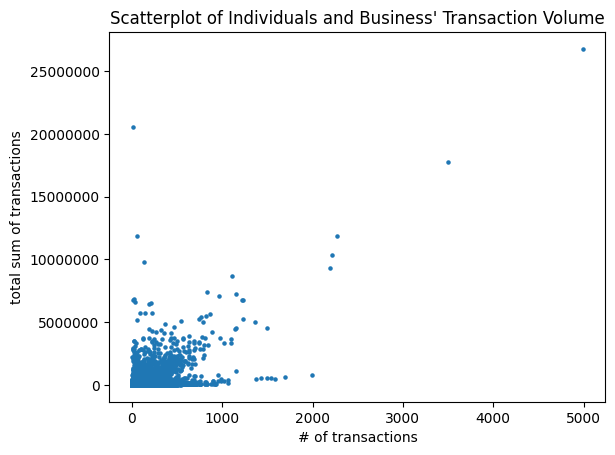

In [17]:
columns = ['customer_id', 'abm_amount', 'card_amount', 'cheque_amount', 'eft_amount', 'emt_amount', 'westernunion_amount', 'wire_amount']
transactions = master_df[columns]

sum_of_transactions = transactions.groupby('customer_id',as_index=False).sum()
sum_of_transactions['total']= sum_of_transactions.iloc[:,1:8].sum(axis=1)

num_of_transactions = transactions.groupby('customer_id', as_index=False).size()

# print(sum_of_transactions.head())
#print(num_of_transactions)

plt.scatter(num_of_transactions['size'], 
            sum_of_transactions['total'],
            s=5)
plt.xlabel('# of transactions')    
plt.ylabel('total sum of transactions') 
plt.ticklabel_format(style = 'plain', axis= 'y')
plt.title('Scatterplot of Individuals and Business\' Transaction Volume')
plt.show()

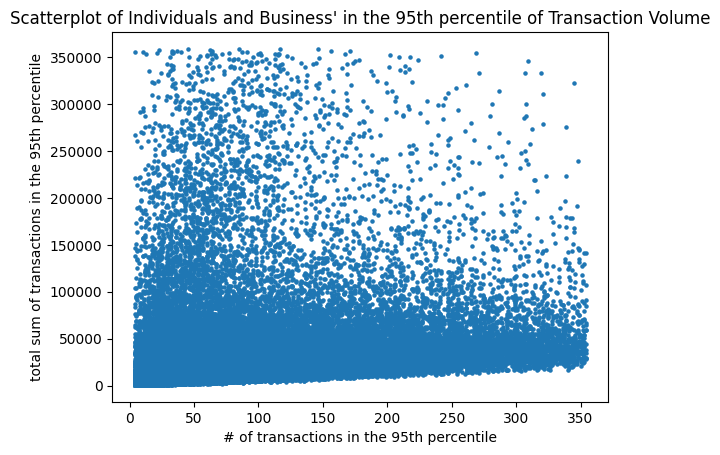

                 size      total
customer_id                     
SYNID0100000167    19   11562.53
SYNID0100000431   108   22360.92
SYNID0100000485    40   10991.32
SYNID0100000539   151   10409.15
SYNID0100000932   219  175514.88


In [18]:
subset_df = pd.concat([
    num_of_transactions.set_index('customer_id')['size'],
    sum_of_transactions.set_index('customer_id')['total']
], axis=1)


lower_x = subset_df['size'].quantile(0.025)
upper_x = subset_df['size'].quantile(0.975)

lower_y = subset_df['total'].quantile(0.025)
upper_y = subset_df['total'].quantile(0.975)

sum_filter = subset_df[
    (subset_df['size'] >= lower_x) & (subset_df['size'] <= upper_x) &
    (subset_df['total'] >= lower_y) & (subset_df['total'] <= upper_y)
    ]

plt.scatter(sum_filter['size'], sum_filter['total'], s = 5)
plt.xlabel('# of transactions in the 95th percentile')    
plt.ylabel('total sum of transactions in the 95th percentile') 
plt.title('Scatterplot of Individuals and Business\' in the 95th percentile of Transaction Volume')
plt.show()

print(sum_filter.head())

In [19]:
check = sum_of_transactions[(sum_of_transactions['customer_id'] =='SYNID0101421130')]

print(subset_df.loc['SYNID0101421130'])

#SYNID0101421130
print(check)
#print(sum_of_transactions)

size       4.00
total    159.45
Name: SYNID0101421130, dtype: float64
          customer_id  abm_amount  card_amount  cheque_amount  eft_amount  \
7487  SYNID0101421130         0.0       159.45            0.0         0.0   

      emt_amount  westernunion_amount  wire_amount   total  
7487         0.0                  0.0          0.0  159.45  


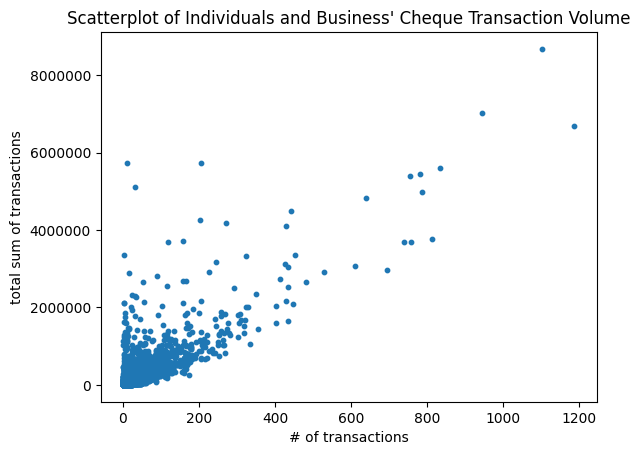

In [20]:
"""A SMALL SCALE SCATTER PLOT OF THE DATA ON ONLY cheque.csv DATA"""

customer_id = people_df['customer_id']
business_id = business_df['customer_id']

#sum of transactions function
totals = cheque_df.groupby('customer_id', as_index= False)['amount_cad'].sum()

mean = totals['amount_cad'].mean() #35671.24
median = totals['amount_cad'].median() #2684.645

#number of transactions
num_transactions = cheque_df.groupby('customer_id', as_index= False).size()

#scatterplot
plt.scatter(num_transactions['size'], 
            totals['amount_cad'],
            s=10 
            )
            
plt.ticklabel_format(style = 'plain', axis= 'y')
plt.xlabel('# of transactions')    
plt.ylabel('total sum of transactions') 
plt.title('Scatterplot of Individuals and Business\' Cheque Transaction Volume')
plt.show()

# print(num_transactions['size'].max())
# print(totals['amount_cad'].max())

C:\Users\silve\AppData\Local\Temp\ipykernel_8924\2560640345.py:16: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  total_invoice_amt = df.pivot_table(


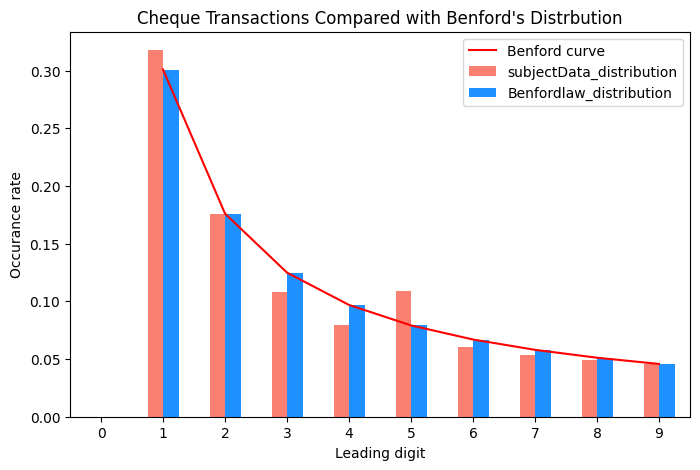

  extract_digit    amount_cad  amount_cad_frequency  subjectData_distribution  \
0             0  1.573000e+01                    39                  0.000162   
1             1  3.226453e+08                 76470                  0.317899   
2             2  1.993137e+08                 42274                  0.175740   
3             3  1.275531e+08                 26086                  0.108444   
4             4  1.171197e+08                 19060                  0.079236   
5             5  1.103433e+08                 26206                  0.108943   
6             6  4.919599e+07                 14622                  0.060786   
7             7  4.927257e+07                 12936                  0.053777   
8             8  3.908367e+07                 11808                  0.049088   
9             9  4.148401e+07                 11047                  0.045924   

   Benfordlaw_distribution  
0                      NaN  
1                 0.301030  
2                 0.1

In [21]:
"""
SMALL SCALE BENFORD's LAW TEST ON THE cheque.csv DATA TO MAKE SURE MOST OF THE TRANSACTIONS ARE 
REAL AND NOT DONE BY MONEY LAUNDERS
"""
df = pd.DataFrame() 

df['amount_cad'] = cheque_df['amount_cad'].copy() 
df['extract_digit'] = df['amount_cad'].astype(str).str[:1] 


first_digit_count = df.pivot_table(
    values = ['amount_cad'],
    index = 'extract_digit', aggfunc= len, fill_value=''  
) 

total_invoice_amt = df.pivot_table(
    values = ['amount_cad'],
    index = 'extract_digit', aggfunc=sum, fill_value=''
)

df2 = total_invoice_amt.merge(first_digit_count, how = 'left',
                              left_on = 'extract_digit',
                              right_index= True,
                              suffixes = ['','_frequency'])

df2['subjectData_distribution'] = df2['amount_cad_frequency']/df2['amount_cad_frequency'].sum()

digits = np.arange(1,10)
benford_df = pd.DataFrame({
    'extract_digit': digits,
    'Benfordlaw_distribution': np.log10(1 + 1/digits)
})

benford_df['extract_digit'] = benford_df['extract_digit'].astype(str)


df2 = df2.merge(benford_df, on='extract_digit', how='left')


fig, ax = plt.subplots(figsize = (8, 5))
df2.reset_index()['Benfordlaw_distribution'].plot(kind = "line", ax = ax, secondary_y = False, color =  'red')
ax.legend(["Benford curve"])
df2.plot(kind = 'bar', x = 'extract_digit', y = ['subjectData_distribution','Benfordlaw_distribution'], 
        ax = ax, color = ['salmon','dodgerblue'], rot = 0)

plt.title('Cheque Transactions Compared with Benford\'s Distrbution')
plt.xlabel('Leading digit')
plt.ylabel('Occurance rate')
plt.show()


# print(first_digit_count)
# print(total_invoice_amt)
print(df2)


